In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data= pd.read_csv('Citas_Digital_Filtrado.csv') 

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       657 non-null    str    
 1   Fecha                                     72 non-null     str    
 2   Nombre Cliente                            652 non-null    str    
 3   Estatus de Lead                           638 non-null    str    
 4   Potencial de compra                       599 non-null    str    
 5   PDM                                       672 non-null    float64
 6   SDC                                       671 non-null    float64
 7   Venta                                     668 non-null    float64
 8   Asesor Asignado                           641 non-null    str    
 9   ¿Por que no ha visitado la agencia?       493 non-null    str    
 10  ¿Por que no hay solicitud de credito?     379 non

In [9]:
data['Potencial de compra'] = (data['Potencial de compra']
                                .astype(str)
                                .str.replace('%', '', regex=False)
                                .str.replace("'", '', regex=False)
                                .str.replace('&', '', regex=False)
                                .str.strip())
data['Potencial de compra'] = pd.to_numeric(data['Potencial de compra'], errors='coerce')
data['Potencial de compra']

0       0.90
1       0.40
2       0.85
3       0.90
4       0.90
       ...  
668     0.50
669     0.50
670    80.00
671     0.80
672     0.50
Name: Potencial de compra, Length: 673, dtype: float64

In [10]:
valores_nulos = data.isnull().sum()
valores_nulos

BDC                                          16
Fecha                                       601
Nombre Cliente                               21
Estatus de Lead                              35
Potencial de compra                          75
PDM                                           1
SDC                                           2
Venta                                         5
Asesor Asignado                              32
¿Por que no ha visitado la agencia?         180
¿Por que no hay solicitud de credito?       294
¿Por que no hubo prueba de manejo ?         318
¿Por que no hubo proceso wow?               309
¿Por que se asigno antes de vistar piso?    320
dtype: int64

In [11]:
data1 = data.bfill()
data1

,BDC,Fecha,Nombre Cliente,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?
0,Saul,2026-06-01,Guillermo,Finalizado,0.90,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s..."
1,Saul,2026-06-01,Roberto,Finalizado,0.40,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso
2,Saul,2026-06-01,Irving,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso
3,Saul,2026-06-01,Oswaldo,Venta,0.90,0.0,0.0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as..."
4,Saul,2026-06-01,Rodrigo,Finalizado,0.90,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,Ignacio,2026-07-21,Carlos Balderrama,Activo,0.50,1.0,1.0,1.0,Mario Varela,NaN,NaN,NaN,NaN,NaN
669,Ignacio,2026-07-21,Andrés Netzahuatl,Activo,0.50,0.0,0.0,0.0,Mauricio,NaN,NaN,NaN,NaN,NaN
670,Ana,2026-07-22,Arat Israel,Activo,80.00,1.0,1.0,0.0,Aurelio,NaN,NaN,NaN,NaN,NaN
671,Ana,2026-07-22,Maira Escalante,Activo,0.80,1.0,1.0,0.0,Pedro Antonio,NaN,NaN,NaN,NaN,NaN


In [12]:
valores_nulos = data1.isnull().sum()
valores_nulos

BDC                                           0
Fecha                                         0
Nombre Cliente                                0
Estatus de Lead                               0
Potencial de compra                           0
PDM                                           0
SDC                                           0
Venta                                         0
Asesor Asignado                               0
¿Por que no ha visitado la agencia?         122
¿Por que no hay solicitud de credito?       170
¿Por que no hubo prueba de manejo ?         181
¿Por que no hubo proceso wow?               181
¿Por que se asigno antes de vistar piso?    181
dtype: int64

In [13]:
cuantitativas = data1[['Potencial de compra', 'PDM', 'SDC', 'Venta']]
cualitativas = data1.drop(columns=['Potencial de compra', 'PDM', 'SDC', 'Venta'])

<Figure size 1500x800 with 0 Axes>

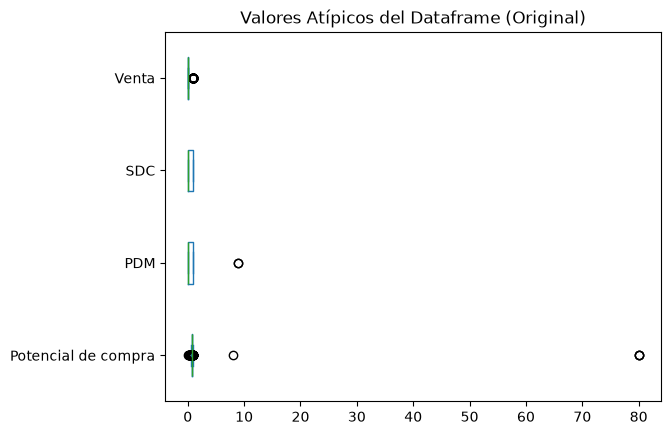

In [14]:
fig = plt.figure(figsize=(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe (Original)")
plt.show()

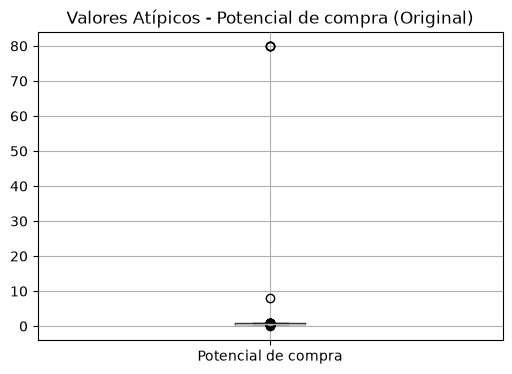

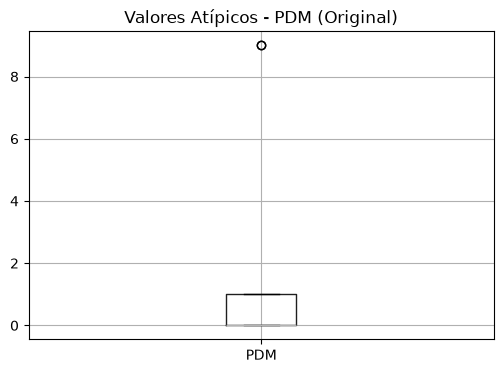

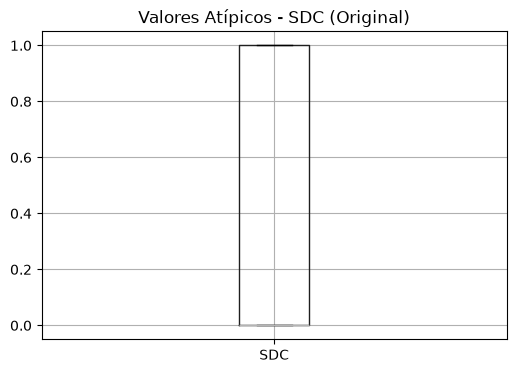

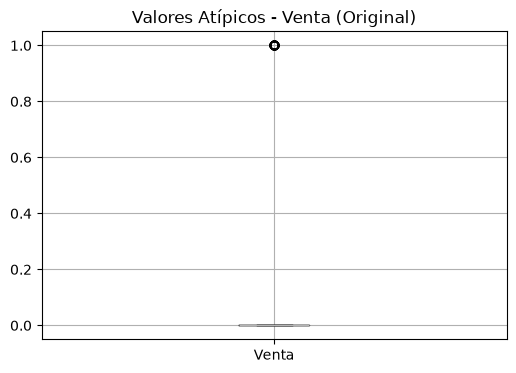

In [15]:
for columna in cuantitativas.columns:
    plt.figure(figsize=(6, 4))
    cuantitativas.boxplot(column=columna)
    plt.title(f"Valores Atípicos - {columna} (Original)")
    plt.show()

In [24]:
y = cuantitativas

percentile25 = y.quantile(0.25) #Q1
percentile75 = y.quantile(0.75) #Q3
iqr = percentile75 - percentile25

Limite_Superior_iqr = percentile75 + 1.5*iqr
Limite_Inferior_iqr = percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
SDC                    2.50
Venta                  0.00
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
SDC                   -1.50
Venta                  0.00
dtype: float64


In [25]:
data3_iqr = cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,NaN,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
668,NaN,1.0,1.0,NaN
669,NaN,0.0,0.0,0.0
670,NaN,1.0,1.0,0.0
671,0.80,1.0,1.0,0.0


In [26]:
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

Potencial de compra    89
PDM                     2
SDC                     0
Venta                  56
dtype: int64

In [27]:
data4_iqr = data3_iqr.copy()
data4_iqr = data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.80,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
668,0.80,1.0,1.0,0.0
669,0.80,0.0,0.0,0.0
670,0.80,1.0,1.0,0.0
671,0.80,1.0,1.0,0.0


In [28]:
valores_nulos = data4_iqr.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

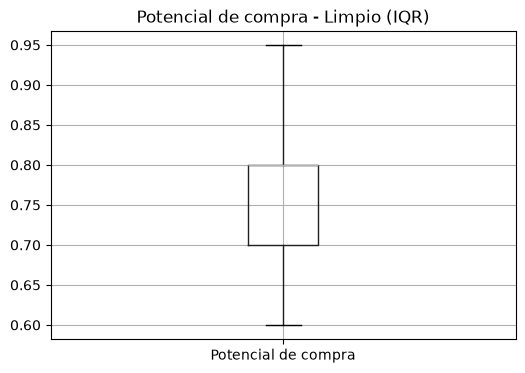

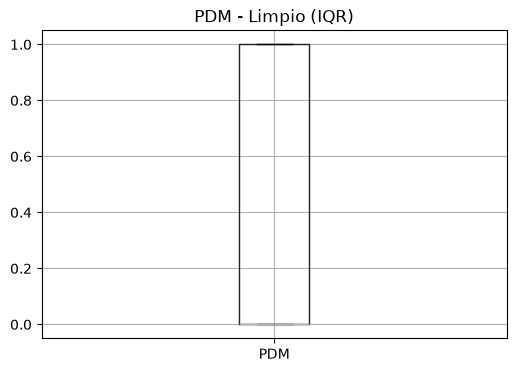

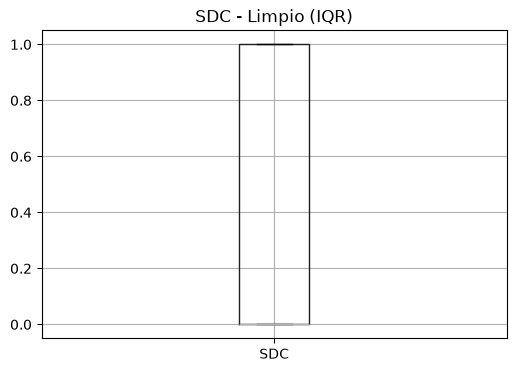

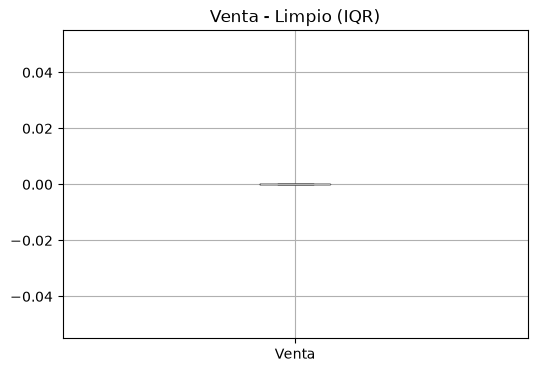

In [29]:
for columna in data4_iqr.columns:
    plt.figure(figsize=(6, 4))
    data4_iqr.boxplot(column=columna)
    plt.title(f"{columna} - Limpio (IQR)")
    plt.show()

In [30]:
Datos_limpios_iqr = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limpios_iqr

,BDC,Fecha,Nombre Cliente,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Potencial de compra,PDM,SDC,Venta
0,Saul,2026-06-01,Guillermo,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",0.90,1.0,0.0,0.0
1,Saul,2026-06-01,Roberto,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,0.80,0.0,0.0,0.0
2,Saul,2026-06-01,Irving,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,0.85,0.0,0.0,0.0
3,Saul,2026-06-01,Oswaldo,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",0.90,0.0,0.0,0.0
4,Saul,2026-06-01,Rodrigo,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,Ignacio,2026-07-21,Carlos Balderrama,Activo,Mario Varela,NaN,NaN,NaN,NaN,NaN,0.80,1.0,1.0,0.0
669,Ignacio,2026-07-21,Andrés Netzahuatl,Activo,Mauricio,NaN,NaN,NaN,NaN,NaN,0.80,0.0,0.0,0.0
670,Ana,2026-07-22,Arat Israel,Activo,Aurelio,NaN,NaN,NaN,NaN,NaN,0.80,1.0,1.0,0.0
671,Ana,2026-07-22,Maira Escalante,Activo,Pedro Antonio,NaN,NaN,NaN,NaN,NaN,0.80,1.0,1.0,0.0


In [31]:
Datos_limpios_iqr.to_csv("Datos_limpios_iqr.csv", index=False)